# Grover Search on a Toy RSA Plaintext

## Goal

This notebook demonstrates **Grover's algorithm** as a quantum search method using a small RSA-style example.

The search problem is:

> Given the RSA public key `(e, n) = (5, 21)` and ciphertext `c = 17`, find a plaintext `m` such that  
> `m^5 mod 21 = 17`.

The correct plaintext is:

`m = 5`

In a 5-qubit search space, this plaintext is represented as:

`00101`

## Connection to the full project

This notebook is part of a larger project about quantum threats to RSA and post-quantum cryptography:

1. RSA baseline and classical factoring
2. Shor's algorithm for factoring `N = 21`
3. **Grover search on a toy RSA plaintext**
4. ML-KEM post-quantum key establishment


## Important Distinction: Grover vs. Shor

Grover's algorithm does **not** directly break RSA by factoring `n`.

The direct quantum threat to RSA is **Shor's algorithm**, because Shor's algorithm can factor the RSA modulus `n`.

Grover's algorithm is included here because it demonstrates **quantum search** and **amplitude amplification**. In this notebook, Grover searches through possible plaintext values and amplifies the state that satisfies the RSA equation.


## Setup

This notebook uses:

- Python
- Qiskit
- Qiskit Aer
- Pandas
- Matplotlib

In Google Colab, uncomment and run the install command below if the packages are missing.


In [3]:
# In Google Colab, uncomment this line if dependencies are missing.
%pip install -q "qiskit>=2.1.0" "qiskit-aer>=0.17.0" "qiskit-ibm-runtime>=0.40.1" pandas matplotlib pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.9 MB/s eta 0:00:00


In [4]:
# Built-in modules
import math

# Data and plotting
import pandas as pd
import matplotlib.pyplot as plt

# Qiskit imports
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.visualization import plot_distribution
from qiskit_aer import AerSimulator


## 1. Toy RSA Search Problem

The RSA equation used in this notebook is:

`c = m^e mod n`

For this toy example:

- `n = 21`
- `e = 5`
- `m = 5`
- `c = 17`

So the search problem is:

`m^5 mod 21 = 17`

A classical brute-force search can check possible values one by one. Grover's algorithm instead amplifies the correct answer in a quantum search space.


In [5]:
# Toy RSA values connected to the RSA/Shor part of the project
toy_n = 21
toy_e = 5
toy_message = 5

# Encrypt the toy message
toy_ciphertext = pow(toy_message, toy_e, toy_n)

print("===== Toy RSA Search Problem =====")
print(f"Public key: (e, n) = ({toy_e}, {toy_n})")
print(f"Original message: {toy_message}")
print(f"Ciphertext: {toy_ciphertext}")
print(f"Verification: {toy_message}^{toy_e} mod {toy_n} = {toy_ciphertext}")


===== Toy RSA Search Problem =====
Public key: (e, n) = (5, 21)
Original message: 5
Ciphertext: 17
Verification: 5^5 mod 21 = 17


## 2. Search Space

The plaintext must be smaller than `n = 21`, but quantum registers use powers of 2.

Since:

- `2^4 = 16`, which is too small
- `2^5 = 32`, which is enough

we use **5 qubits**.

This means the quantum search space contains 32 bitstrings, but only decimal values from `0` to `20` are valid plaintext candidates for this toy RSA setup.


In [6]:
# n = 21 requires 5 qubits because 2^5 = 32
num_qubits = math.ceil(math.log2(toy_n))
search_space_size = 2**num_qubits

# Find all m such that m^e mod n equals the ciphertext.
# For this toy example, this is used to define the marked state for the oracle.
marked_states = []

for candidate_message in range(search_space_size):
    if candidate_message < toy_n and pow(candidate_message, toy_e, toy_n) == toy_ciphertext:
        marked_states.append(format(candidate_message, f"0{num_qubits}b"))

print(f"Number of qubits = {num_qubits}")
print(f"Search space size = {search_space_size}")
print(f"Marked states = {marked_states}")


Number of qubits = 5
Search space size = 32
Marked states = ['00101']


## 3. Classical Brute-Force Baseline

Before running Grover's algorithm, I use a classical brute-force search as a baseline.

The classical method checks possible messages one at a time until it finds a message satisfying:

`m^5 mod 21 = 17`


In [7]:
classical_attempts = 0
classical_found = None

for candidate_message in range(search_space_size):
    classical_attempts += 1

    if candidate_message < toy_n and pow(candidate_message, toy_e, toy_n) == toy_ciphertext:
        classical_found = candidate_message
        break

print("===== Classical Brute Force =====")
print(f"Classical brute-force found message: {classical_found}")
print(f"Number of classical attempts: {classical_attempts}")


===== Classical Brute Force =====
Classical brute-force found message: 5
Number of classical attempts: 6


## 4. Oracle Building Block

Grover's algorithm needs an **oracle**.

The oracle marks the correct state by applying a phase flip to it. Here, the marked state is:

`00101`

which represents decimal value:

`5`

The oracle does not reveal the answer directly. It only flips the phase of the correct state. Then Grover's diffuser amplifies the probability of measuring that state.

Important Qiskit note: Qiskit uses **little-endian** qubit ordering, so the target bitstring is reversed inside the oracle construction.


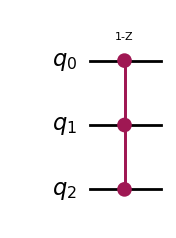

In [8]:
# Small demonstration of a multi-controlled Z gate.
# This is the phase-flip building block used inside the Grover oracle.

mcmt_example = QuantumCircuit(3)
mcmt_example.compose(MCMTGate(ZGate(), 3 - 1, 1), inplace=True)
mcmt_example.draw(output="mpl", style="iqp")


In [9]:
def grover_oracle(marked_states):
    """
    Build a Grover oracle for one or more marked states.

    Each marked state receives a phase flip.

    Parameters
    ----------
    marked_states : str or list[str]
        Bitstring(s) to mark, such as "00101".

    Returns
    -------
    QuantumCircuit
        Oracle circuit that phase-flips the marked state(s).
    """
    if isinstance(marked_states, str):
        marked_states = [marked_states]

    if not marked_states:
        raise ValueError("At least one marked state is required.")

    num_qubits = len(marked_states[0])

    if any(len(state) != num_qubits for state in marked_states):
        raise ValueError("All marked states must have the same length.")

    if any(bit not in "01" for state in marked_states for bit in state):
        raise ValueError("Marked states must be bitstrings containing only 0 and 1.")

    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        # Reverse bitstring because Qiskit uses little-endian qubit ordering.
        reversed_target = target[::-1]

        # Find positions where the target bit is 0.
        # X gates convert open controls into closed controls.
        zero_indices = [
            index for index, bit in enumerate(reversed_target) if bit == "0"
        ]

        qc.x(zero_indices)

        # Apply multi-controlled Z phase flip.
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)

        # Undo X gates.
        qc.x(zero_indices)

    return qc


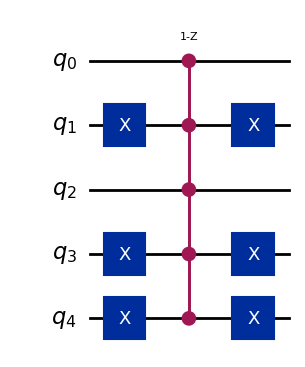

In [10]:
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")


## 5. Grover Operator and Optimal Iterations

Grover's algorithm has two main pieces:

1. **Oracle**: flips the phase of the correct answer.
2. **Diffuser**: amplifies the probability of the marked answer.

The approximate optimal number of Grover iterations is:

`floor(π / (4 * asin(sqrt(M / N))))`

where:

- `N` = search space size
- `M` = number of marked states

For this notebook:

- `N = 32`
- `M = 1`

So the optimal number of iterations is expected to be around 4.


In [11]:
grover_op = grover_operator(oracle)

num_solutions = len(marked_states)
search_space_size = 2**grover_op.num_qubits

optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(num_solutions / search_space_size)))
)

print(f"Search space size: {search_space_size}")
print(f"Number of marked states: {num_solutions}")
print(f"Optimal number of Grover iterations: {optimal_num_iterations}")


Search space size: 32
Number of marked states: 1
Optimal number of Grover iterations: 4


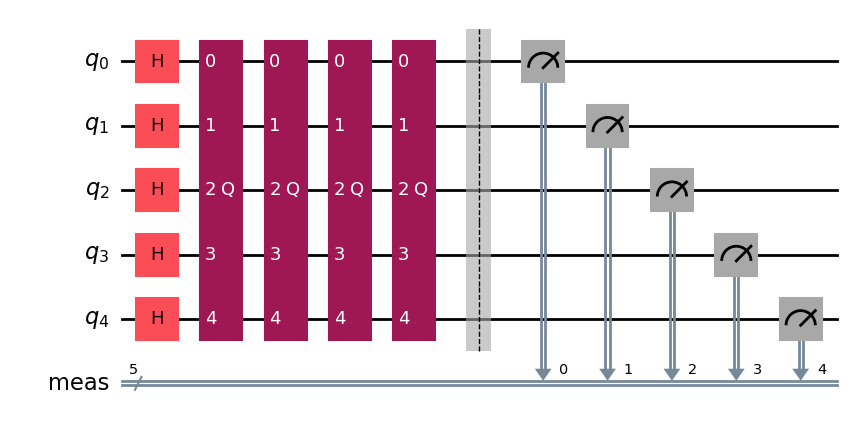

In [12]:
# Build the full Grover circuit.
qc = QuantumCircuit(grover_op.num_qubits)

# Create an equal superposition of all possible basis states.
qc.h(range(grover_op.num_qubits))

# Apply the Grover operator the optimal number of times.
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)

# Measure all qubits.
qc.measure_all()

qc.draw(output="mpl", style="iqp")


## 6. Run the Grover Circuit on a Simulator

The simulator gives the main reproducible result for this notebook.

With the correct number of Grover iterations, the marked state `00101` should appear with high probability.


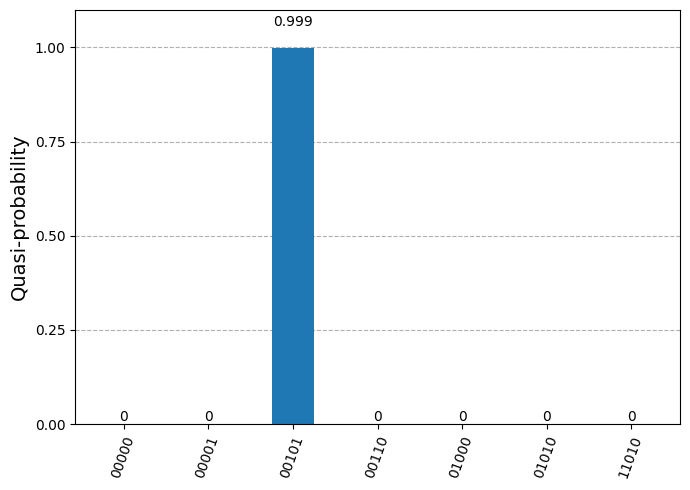

In [13]:
simulator = AerSimulator(seed_simulator=42)
shots = 10_000

# Transpile the circuit for the Aer simulator.
qc_sim = transpile(
    qc,
    simulator,
    optimization_level=1,
    seed_transpiler=42
)

sim_result = simulator.run(qc_sim, shots=shots).result()
sim_counts = sim_result.get_counts()

plot_distribution(sim_counts)


In [14]:
most_likely_bitstring = max(sim_counts, key=sim_counts.get)
recovered_message = int(most_likely_bitstring, 2)

success_probability = sum(
    sim_counts.get(state, 0) for state in marked_states
) / shots

print("===== Grover Simulator Result =====")
print(f"Most likely measured bitstring: {most_likely_bitstring}")
print(f"Recovered message: {recovered_message}")
print(f"Target message: {toy_message}")
print(f"Marked states: {marked_states}")
print(f"Success probability: {success_probability:.4f}")


===== Grover Simulator Result =====
Most likely measured bitstring: 00101
Recovered message: 5
Target message: 5
Marked states: ['00101']
Success probability: 0.9993


## 7. Success Probability vs. Number of Grover Iterations

Grover's algorithm should not be repeated forever.

If there are too few iterations, the correct state is not amplified enough. If there are too many iterations, the probability can rotate away from the correct answer.

This experiment shows how the success probability changes as the number of Grover iterations changes.


===== Grover Iteration Experiment =====
   Grover iterations Most likely state  Success probability
0                  0             01110               0.0309
1                  1             00101               0.2519
2                  2             00101               0.6028
3                  3             00101               0.8996
4                  4             00101               0.9993
5                  5             00101               0.8625
6                  6             00101               0.5425
7                  7             00101               0.2055
8                  8             10000               0.0151
9                  9             00101               0.0533


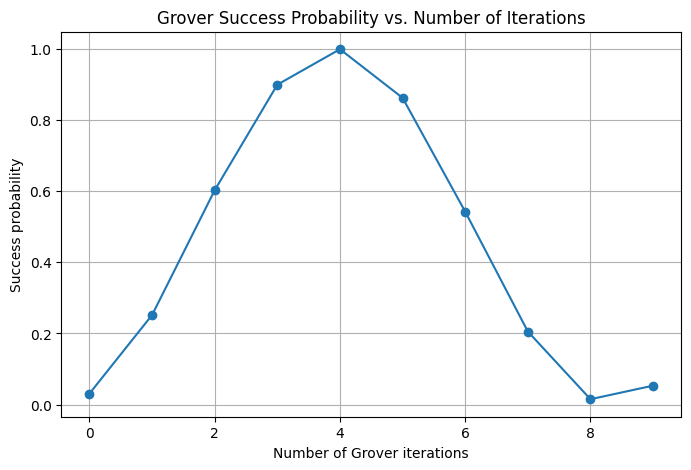

In [15]:
def build_grover_circuit(marked_states, iterations):
    """
    Build a Grover circuit for a selected number of iterations.
    """
    oracle = grover_oracle(marked_states)
    grover_op = grover_operator(oracle)

    qc_test = QuantumCircuit(grover_op.num_qubits)

    # Create equal superposition.
    qc_test.h(range(grover_op.num_qubits))

    # Apply Grover operator.
    if iterations > 0:
        qc_test.compose(grover_op.power(iterations), inplace=True)

    qc_test.measure_all()

    return qc_test


iteration_results = []

for iterations in range(0, 10):
    test_qc = build_grover_circuit(marked_states, iterations)

    test_qc_sim = transpile(
        test_qc,
        simulator,
        optimization_level=1,
        seed_transpiler=42
    )

    result = simulator.run(test_qc_sim, shots=shots).result()
    counts = result.get_counts()

    iteration_success_probability = sum(
        counts.get(state, 0) for state in marked_states
    ) / shots

    most_likely_state = max(counts, key=counts.get)

    iteration_results.append({
        "Grover iterations": iterations,
        "Most likely state": most_likely_state,
        "Success probability": iteration_success_probability
    })

df_iterations = pd.DataFrame(iteration_results)

print("===== Grover Iteration Experiment =====")
print(df_iterations)

plt.figure(figsize=(8, 5))
plt.plot(
    df_iterations["Grover iterations"],
    df_iterations["Success probability"],
    marker="o"
)
plt.xlabel("Number of Grover iterations")
plt.ylabel("Success probability")
plt.title("Grover Success Probability vs. Number of Iterations")
plt.grid(True)
plt.show()


## 8. Classical vs. Grover Comparison

This comparison is educational rather than a claim that the notebook breaks real RSA.

The classical baseline checks candidates one by one. Grover's algorithm uses amplitude amplification to make the correct state more likely to appear after measurement.


In [16]:
comparison = pd.DataFrame([
    {
        "Method": "Classical brute force",
        "Search task": "Find m such that m^e mod n = ciphertext",
        "Result": f"Found m = {classical_found}",
        "Cost / behavior": f"{classical_attempts} attempts"
    },
    {
        "Method": "Grover search",
        "Search task": "Amplify the correct plaintext state",
        "Result": f"Most likely state = {most_likely_bitstring}",
        "Cost / behavior": f"Optimal iterations = {optimal_num_iterations}"
    }
])

print("===== Classical vs. Grover Comparison =====")
print(comparison)


===== Classical vs. Grover Comparison =====
                  Method                              Search task  \
0  Classical brute force  Find m such that m^e mod n = ciphertext   
1          Grover search      Amplify the correct plaintext state   

                      Result         Cost / behavior  
0                Found m = 5              6 attempts  
1  Most likely state = 00101  Optimal iterations = 4  


## Optional: Run on IBM Quantum Hardware

The simulator result above is the main reproducible result.

This hardware section is optional because IBM Quantum hardware requires:

- an IBM Quantum account
- a saved account configuration
- queue time
- device access
- noise-aware interpretation

Do **not** paste API keys directly into a notebook that will be uploaded to GitHub. Save credentials outside the notebook using IBM/Qiskit account tools or environment variables.

By default, the cell below is disabled with:

`RUN_HARDWARE = False`


In [17]:
RUN_HARDWARE = False

if RUN_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService
    from qiskit_ibm_runtime import SamplerV2 as Sampler
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    # Assumes your IBM Quantum account is already saved outside this notebook.
    service = QiskitRuntimeService()

    # Choose an available real backend.
    backends = service.backends(operational=True, simulator=False)
    for backend_option in backends:
        print(backend_option.name)

    backend = service.least_busy(operational=True, simulator=False)
    print(f"Selected backend: {backend.name}")

    pm = generate_preset_pass_manager(
        optimization_level=2,
        backend=backend
    )

    qc_hardware = pm.run(qc)

    print(f"Original circuit depth: {qc.depth()}")
    print(f"Hardware circuit depth: {qc_hardware.depth()}")
    print(f"Hardware circuit operations: {qc_hardware.count_ops()}")

    sampler = Sampler(backend)
    job = sampler.run([qc_hardware], shots=1024)
    print(f"Job ID: {job.job_id()}")

    hardware_result = job.result()
    hardware_counts = hardware_result[0].data.meas.get_counts()

    print("===== Hardware Counts =====")
    print(hardware_counts)

    total_hardware_shots = sum(hardware_counts.values())
    most_likely_hardware_bitstring = max(hardware_counts, key=hardware_counts.get)

    hardware_success_probability = sum(
        hardware_counts.get(state, 0) for state in marked_states
    ) / total_hardware_shots

    print("===== Grover Hardware Result =====")
    print(f"Most likely hardware bitstring: {most_likely_hardware_bitstring}")
    print(f"Marked states: {marked_states}")
    print(f"Hardware success probability: {hardware_success_probability:.4f}")

    plot_distribution(hardware_counts)
else:
    print("Hardware section skipped. Set RUN_HARDWARE = True only when you want to run on IBM Quantum hardware.")


Hardware section skipped. Set RUN_HARDWARE = True only when you want to run on IBM Quantum hardware.


## Final Result

| Question | Answer |
|---|---|
| What was searched? | A toy RSA plaintext `m` |
| Public key | `(e, n) = (5, 21)` |
| Ciphertext | `17` |
| Correct plaintext | `m = 5` |
| Marked quantum state | `00101` |
| Search space size | `32` states |
| Best Grover iteration count | `4` |
| Main result | The simulator should measure `00101` with high probability |

## Limitations

This notebook is a **toy educational demonstration**.

Important limitations:

1. `n = 21` is intentionally small.
2. This does not break real RSA.
3. Grover's algorithm is not the direct RSA factoring attack.
4. The marked state is precomputed classically to build the oracle.
5. A full RSA-search oracle would require a reversible quantum circuit that computes `m^e mod n`.
6. Real quantum hardware results may be noisy because of gate errors, measurement errors, decoherence, and transpilation overhead.

## Next Improvement

A stronger future version would build a fully reversible oracle that checks:

`m^e mod n == c`

inside the quantum circuit instead of precomputing the marked state classically.
